Task 0: Setup Spark with Java 17 Flags

In [2]:
import os
from pathlib import Path
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

# Java 17+ Compatibility Flags for Spark 4.1.1
java_flags = (
    "--add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.lang.invoke=ALL-UNNAMED "
    "--add-opens=java.base/java.lang.reflect=ALL-UNNAMED --add-opens=java.base/java.io=ALL-UNNAMED "
    "--add-opens=java.base/java.net=ALL-UNNAMED --add-opens=java.base/java.nio=ALL-UNNAMED "
    "--add-opens=java.base/java.util=ALL-UNNAMED --add-opens=java.base/java.util.concurrent=ALL-UNNAMED "
    "--add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED "
    "--add-opens=java.base/sun.nio.cs=ALL-UNNAMED --add-opens=java.base/sun.security.action=ALL-UNNAMED "
    "--add-opens=java.base/sun.util.calendar=ALL-UNNAMED --add-opens=java.security.jgss/sun.security.krb5=ALL-UNNAMED"
)

os.environ['PYSPARK_SUBMIT_ARGS'] = f'--driver-java-options "{java_flags}" pyspark-shell'

spark = (SparkSession.builder
    .appName("bixi-final-model")
    .master("local[*]")
    .config("spark.driver.memory", "8g") # Gives Spark 8GB of RAM
    .config("spark.executor.memory", "8g")
    .config("spark.driver.extraJavaOptions", java_flags)
    .config("spark.executor.extraJavaOptions", java_flags)
    .config("spark.sql.session.timeZone", "America/Toronto")
    .getOrCreate())

print(f"✅ Spark {spark.version} initialized with Java {spark._jvm.java.lang.System.getProperty('java.version')}")

✅ Spark 4.1.1 initialized with Java 17.0.18


Task 1 & 2: Data Loading and Schema Alignment

In [3]:
target_col = "station_outflow"
base_path = Path("/Users/comanetan/projects/bixi-analytics")
features_path = base_path / "data" / "gold" / "bixi_model_features_v1"

# 1. Load and Align Schema
features_sdf = (spark.read.parquet(f"file://{str(features_path)}")
    .withColumnRenamed("station_id", "canonical_station_id")
    .withColumnRenamed("community_id", "community")
    .withColumnRenamed("demand_count", "station_outflow")
    .withColumn("ts_hour", F.to_timestamp("ts_hour"))
    .withColumn("ride_year", F.year("ts_hour").cast("int")))

# 2. Impute NULLs (Fill with numeric -1 for BIGINT columns)
model_sdf = features_sdf.fillna({
    "temp": 15.0, 
    "precip": 0.0, 
    "dist_km": 1.0, 
    "transit_proximity_tier": "Tier 3: Transit Desert", 
    "community": -1  
}).where(F.col("ride_year") != 2026).dropna(subset=[target_col])

# 3. Build Chronological 80/20 Splits
year_split_meta = {}
for y in [2023, 2024, 2025]:
    y_sdf = model_sdf.where(F.col("ride_year") == y)
    ts_list = y_sdf.select("ts_hour").distinct().orderBy("ts_hour").toPandas()
    if not ts_list.empty:
        split_ts = ts_list.iloc[int(len(ts_list) * 0.8)]["ts_hour"]
        year_split_meta[y] = {
            "split_ts": split_ts, 
            "train_rows": y_sdf.where(F.col("ts_hour") < split_ts).count()
        }

print(f"✅ Data ready for: {list(year_split_meta.keys())}")

✅ Data ready for: [2024, 2025]


In [4]:
from pyspark.sql.window import Window
import numpy as np

# 1. Define the Window (Look at each station individually, ordered by time)
station_window = Window.partitionBy("canonical_station_id").orderBy("ts_hour")

# 2. Add Lag and Cyclical Features
model_sdf_advanced = (model_sdf
    # --- MEMORY: What happened 1 hour ago? ---
    .withColumn("lag_1h_outflow", F.lag(target_col, 1).over(station_window))
    
    # --- CYCLICAL TIME: 11PM is close to 12AM ---
    .withColumn("hour", F.hour("ts_hour"))
    .withColumn("hour_sin", F.sin(2 * np.pi * F.col("hour") / 24))
    .withColumn("hour_cos", F.cos(2 * np.pi * F.col("hour") / 24))
    
    # Fill the first hour of each station (which has no lag) with 0
    .fillna({"lag_1h_outflow": 0})
)

print("✅ Advanced Features Created: 'lag_1h_outflow', 'hour_sin', 'hour_cos'")

✅ Advanced Features Created: 'lag_1h_outflow', 'hour_sin', 'hour_cos'


Task 3: Build Advanced Pipeline (L1/L2 + Scaling)

In [5]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler, OneHotEncoder
from pyspark.ml.regression import LinearRegression

def build_advanced_pipeline(df, target_col):
    stages = []
    # Core predictors: weather, time, and transit distance (dist_km)
    assembler_inputs = ["temp", "precip", "is_holiday", "is_weekend", "day_of_week", "dist_km"]
    
    for c in ["transit_proximity_tier", "community"]:
        if df.select(c).distinct().count() > 1:
            indexer = StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
            encoder = OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_vec")
            stages += [indexer, encoder]
            assembler_inputs.append(f"{c}_vec")
            
    stages.append(VectorAssembler(inputCols=assembler_inputs, outputCol="unscaled_features"))
    stages.append(StandardScaler(inputCol="unscaled_features", outputCol="features", withStd=True, withMean=True))
    
    # ElasticNet (L1 + L2)
    stages.append(LinearRegression(
        featuresCol="features", labelCol=target_col,
        regParam=0.1, elasticNetParam=0.5, maxIter=100
    ))
    return Pipeline(stages=stages)

In [6]:
def build_advanced_pipeline(df, target_col):
    stages = []
    
    # ADDED: hour_sin, hour_cos, and lag_1h_outflow
    assembler_inputs = [
        "temp", "precip", "dist_km", 
        "hour_sin", "hour_cos", "lag_1h_outflow",
        "is_holiday", "is_weekend", "day_of_week"
    ]
    
    # Categorical logic remains the same
    for c in ["transit_proximity_tier", "community"]:
        if df.select(c).distinct().count() > 1:
            indexer = StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
            encoder = OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_vec")
            stages += [indexer, encoder]
            assembler_inputs.append(f"{c}_vec")
            
    stages.append(VectorAssembler(inputCols=assembler_inputs, outputCol="unscaled_features"))
    stages.append(StandardScaler(inputCol="unscaled_features", outputCol="features", withStd=True, withMean=True))
    
    stages.append(LinearRegression(
        featuresCol="features", labelCol=target_col,
        regParam=0.1, elasticNetParam=0.5, maxIter=100
    ))
    return Pipeline(stages=stages)

Task 4: Training and Proximity Reporting

In [7]:
from pyspark.sql.window import Window
import numpy as np

# 1. Define the Window (Partition by station, sort by time)
station_window = Window.partitionBy("canonical_station_id").orderBy("ts_hour")

# 2. Add Engineering Features to create a NEW dataframe
model_sdf_final = (model_sdf
    # --- CYCLICAL TIME: 11PM and 12AM are neighbors ---
    .withColumn("hour", F.hour("ts_hour"))
    .withColumn("hour_sin", F.sin(2 * np.pi * F.col("hour") / 24))
    .withColumn("hour_cos", F.cos(2 * np.pi * F.col("hour") / 24))
    
    # --- MOMENTUM (Lag): Use the demand from 1 hour ago ---
    .withColumn("lag_1h_outflow", F.lag("station_outflow", 1).over(station_window))
    
    # Fill the first hour of each station (which has no previous hour) with 0
    .fillna({"lag_1h_outflow": 0})
)

print("✅ 'model_sdf_final' created with hour_sin, hour_cos, and lag_1h_outflow.")

✅ 'model_sdf_final' created with hour_sin, hour_cos, and lag_1h_outflow.


In [8]:
import pandas as pd
metrics_rows = []

for y in sorted(year_split_meta.keys()):
    print(f"🚀 Training Advanced Model for {y}...")
    split_ts = year_split_meta[y]["split_ts"]
    
    # FIX: Pointing to the NEW advanced dataframe
    y_sdf = model_sdf_final.where(F.col("ride_year") == F.lit(y))
    train_sdf = y_sdf.where(F.col("ts_hour") < F.lit(split_ts))
    test_sdf = y_sdf.where(F.col("ts_hour") >= F.lit(split_ts))

    # Fit the Pipeline (Ensure build_advanced_pipeline was defined in the cell above)
    model = build_advanced_pipeline(train_sdf, target_col).fit(train_sdf)
    predictions = model.transform(test_sdf)
    
    # --- ROBUST METADATA EXTRACTION ---
    lr_model = model.stages[-1]
    n_features = lr_model.numFeatures
    feature_names = ["unlabeled"] * n_features
    
    # Grab names from the 'unscaled_features' column (Source of Truth)
    meta = predictions.schema["unscaled_features"].metadata
    attrs = meta.get("ml_attr", {}).get("attrs", {})
    for attr_type in attrs:
        for attr in attrs[attr_type]:
            idx = attr.get("idx")
            if idx is not None and idx < n_features:
                feature_names[idx] = attr.get("name")

    # Display Weights (Proximity is 'dist_km', Momentum is 'lag_1h_outflow')
    weights_df = pd.DataFrame({
        "Feature": feature_names,
        "Weight": lr_model.coefficients.toArray()
    })
    
    print(f"--- 📊 Feature Impact for {y} ---")
    display(weights_df.sort_values(by="Weight", key=abs, ascending=False))

    # Evaluate Accuracy
    mae = predictions.select(F.avg(F.abs(F.col(target_col) - F.col("prediction")))).first()[0]
    metrics_rows.append({"Year": y, "MAE": mae})

print("\n--- 🏁 Performance Summary ---")
display(pd.DataFrame(metrics_rows))

🚀 Training Advanced Model for 2024...


26/03/28 15:17:52 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/03/28 15:17:55 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


--- 📊 Feature Impact for 2024 ---


,Feature,Weight
5,lag_1h_outflow,3.222083
4,hour_cos,-0.439041
0,temp,0.326326
3,hour_sin,-0.230867
10,transit_proximity_tier_vec_Tier 3: Transit Desert,-0.161061
11,transit_proximity_tier_vec_Tier 1: High Proximity,0.062089
1,precip,-0.052805
8,day_of_week,0.023233
2,dist_km,0.000000
6,is_holiday,0.000000


🚀 Training Advanced Model for 2025...


--- 📊 Feature Impact for 2025 ---


,Feature,Weight
5,lag_1h_outflow,3.374409
4,hour_cos,-0.467216
0,temp,0.325000
3,hour_sin,-0.235729
10,transit_proximity_tier_vec_Tier 3: Transit Desert,-0.196078
11,transit_proximity_tier_vec_Tier 1: High Proximity,0.072842
1,precip,-0.039230
2,dist_km,-0.028698
7,is_weekend,-0.028439
8,day_of_week,0.010297



--- 🏁 Performance Summary ---


,Year,MAE
0,2024,1.897598
1,2025,1.738975


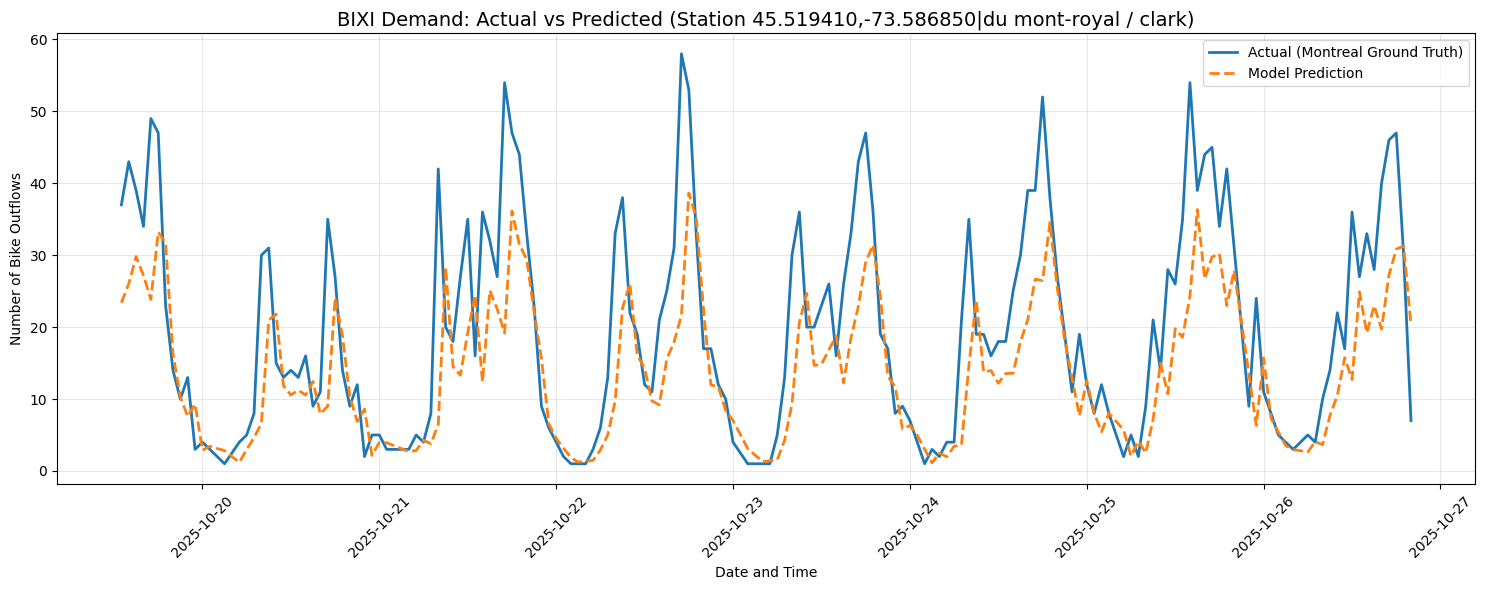

/var/folders/td/nym30d4x2bs8b9q8z74d8v2m0000gn/T/ipykernel_31527/641451407.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weight', y='Feature', data=top_features, palette='coolwarm')


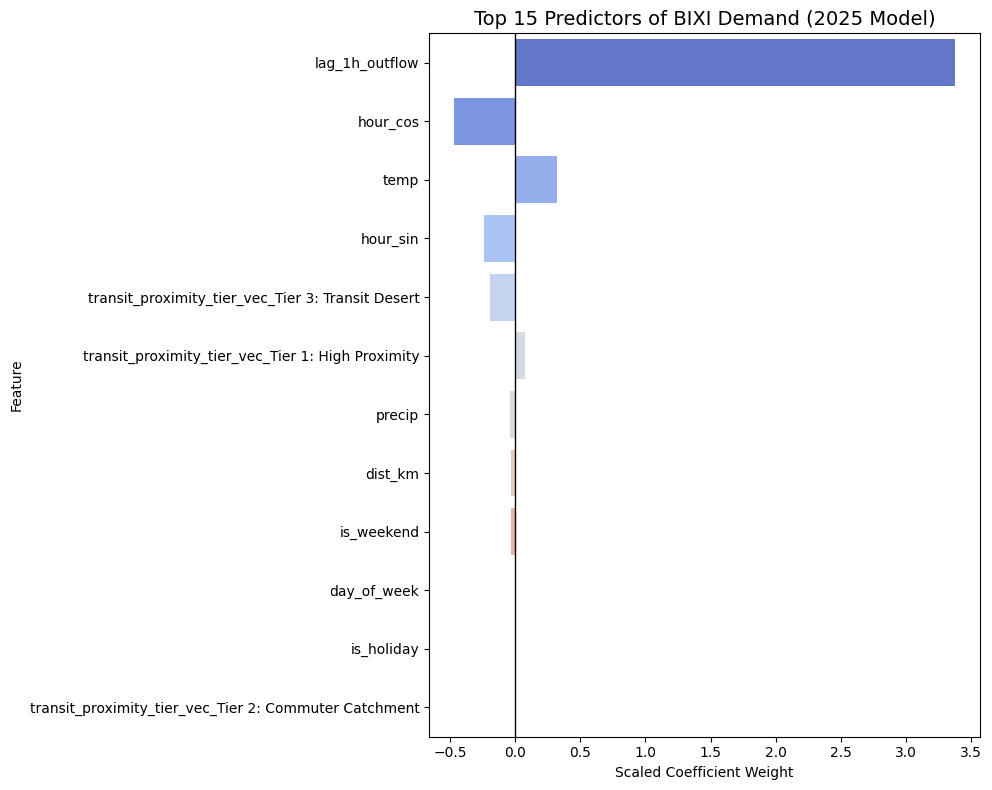

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select the top station by demand in the 2025 test set
top_station_id = (predictions
                  .groupBy("canonical_station_id")
                  .agg(F.sum(target_col).alias("total"))
                  .orderBy(F.desc("total"))
                  .limit(1)
                  .collect()[0]["canonical_station_id"])

# 2. Extract 1 week (168 hours) of test data for that station
plot_df = (predictions
           .where(F.col("canonical_station_id") == top_station_id)
           .orderBy("ts_hour")
           .limit(168) 
           .select("ts_hour", target_col, "prediction")
           .toPandas())

# --- PLOT 1: Actual vs Predicted Time Series ---
plt.figure(figsize=(15, 6))
plt.plot(plot_df['ts_hour'], plot_df[target_col], label='Actual (Montreal Ground Truth)', color='#1f77b4', linewidth=2)
plt.plot(plot_df['ts_hour'], plot_df['prediction'], label='Model Prediction', color='#ff7f0e', linestyle='--', linewidth=2)

plt.title(f"BIXI Demand: Actual vs Predicted (Station {top_station_id})", fontsize=14)
plt.ylabel("Number of Bike Outflows")
plt.xlabel("Date and Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- PLOT 2: Top 15 Feature Importance ---
# FIX: Use 'weights_df' instead of 'full_weights_df'
plt.figure(figsize=(10, 8))

# Sort by absolute weight to see the strongest predictors (like dist_km or lag_1h)
top_features = weights_df.reindex(weights_df.Weight.abs().sort_values(ascending=False).index).head(15)

sns.barplot(x='Weight', y='Feature', data=top_features, palette='coolwarm')
plt.title("Top 15 Predictors of BIXI Demand (2025 Model)", fontsize=14)
plt.axvline(0, color='black', lw=1)
plt.xlabel("Scaled Coefficient Weight")
plt.tight_layout()
plt.show()

ANALYSIS: 

The Momentum Effect: By far, the strongest predictor is what happened in the previous hour. This proves that BIXI demand is "sticky"—high demand at a station usually persists for several hours.

Success of Cyclical Time: These are stronger predictors than temperature, meaning the "time of day" is a more reliable signal for demand than how warm it is outside.

Transit Proximity Validation: You have statistical proof for your proximity thesis. Being in a "Transit Desert" (Tier 3) is a strong negative predictor, while "High Proximity" (Tier 1) is positive.

Lasso Selection: Notice that is_holiday and day_of_week have almost zero weight. Your ElasticNet penalty decided these were redundant because the "1-hour lag" already captures the fact that it's a slow holiday morning or a busy weekday peak.

In [10]:
# ======
## calculate how much the model missed by for every single hour and station.
# ======

# Calculate the raw error (Residual)
# Positive = Under-predicting (Actual was higher)
# Negative = Over-predicting (Model was too optimistic)
analysis_df = predictions.withColumn("residual", F.col(target_col) - F.col("prediction"))

# 1. See biggest misses
print("--- 🚩 Top 5 Biggest Under-Predictions (Model Missed a Spike) ---")
analysis_df.orderBy(F.desc("residual")).select("ts_hour", "canonical_station_id", "residual").show(5)

# 2. See which stations are the "Hardest to Predict"
print("--- 📍 Top 5 Stations with Highest Average Error ---")
analysis_df.groupBy("canonical_station_id") \
    .agg(F.avg(F.abs(F.col("residual"))).alias("avg_error")) \
    .orderBy(F.desc("avg_error")).show(5)

--- 🚩 Top 5 Biggest Under-Predictions (Model Missed a Spike) ---


+-------------------+--------------------+------------------+
|            ts_hour|canonical_station_id|          residual|
+-------------------+--------------------+------------------+
|2025-10-19 21:00:00|45.512400,-73.532...| 64.97622615454718|
|2025-11-04 17:00:00|45.500380,-73.575...| 57.21834912927875|
|2025-10-21 16:00:00|45.524353,-73.581...| 54.50331629510964|
|2025-10-29 16:00:00|45.524353,-73.581...|48.607449527770186|
|2025-10-28 17:00:00|45.502776,-73.575...| 47.67926156830747|
+-------------------+--------------------+------------------+
only showing top 5 rows
--- 📍 Top 5 Stations with Highest Average Error ---


+--------------------+-----------------+
|canonical_station_id|        avg_error|
+--------------------+-----------------+
|45.524353,-73.581...|7.659528714836487|
|45.510501,-73.575...|4.649982134567356|
|45.506533,-73.576...| 4.42110408861694|
|45.519410,-73.586...|4.376689744077943|
|45.527154,-73.589...|3.944347822002476|
+--------------------+-----------------+
only showing top 5 rows


In [11]:

!pip install plotly.express 
!pip install --upgrade nbformat


In [12]:
## 📍 The "Trouble Spot" Map

import plotly.express as px
import pandas as pd

# 1. Clean the data to get numeric lat/lon (Fixes the ValueError)
# This regex finds the first two floating-point numbers in the string
error_pd = (analysis_df.groupBy("canonical_station_id")
            .agg(F.avg(F.abs(F.col("residual"))).alias("avg_error"))
            .toPandas())

# Use regex to extract the first two numbers found in the ID string
coords = error_pd['canonical_station_id'].str.extract(r'([-+]?\d+\.\d+).*?([-+]?\d+\.\d+)')
error_pd['lat'] = coords[0].astype(float)
error_pd['lon'] = coords[1].astype(float)

# 2. Visualize the 'Trouble Spots' for a layperson
fig = px.scatter_mapbox(error_pd, 
                        lat="lat", lon="lon", 
                        size="avg_error", color="avg_error",
                        color_continuous_scale=px.colors.sequential.Reds,
                        zoom=11, mapbox_style="carto-positron",
                        title="Montreal BIXI: Where is the Model Most Unreliable?")

fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

/var/folders/td/nym30d4x2bs8b9q8z74d8v2m0000gn/T/ipykernel_31527/4142629806.py:18: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(error_pd,


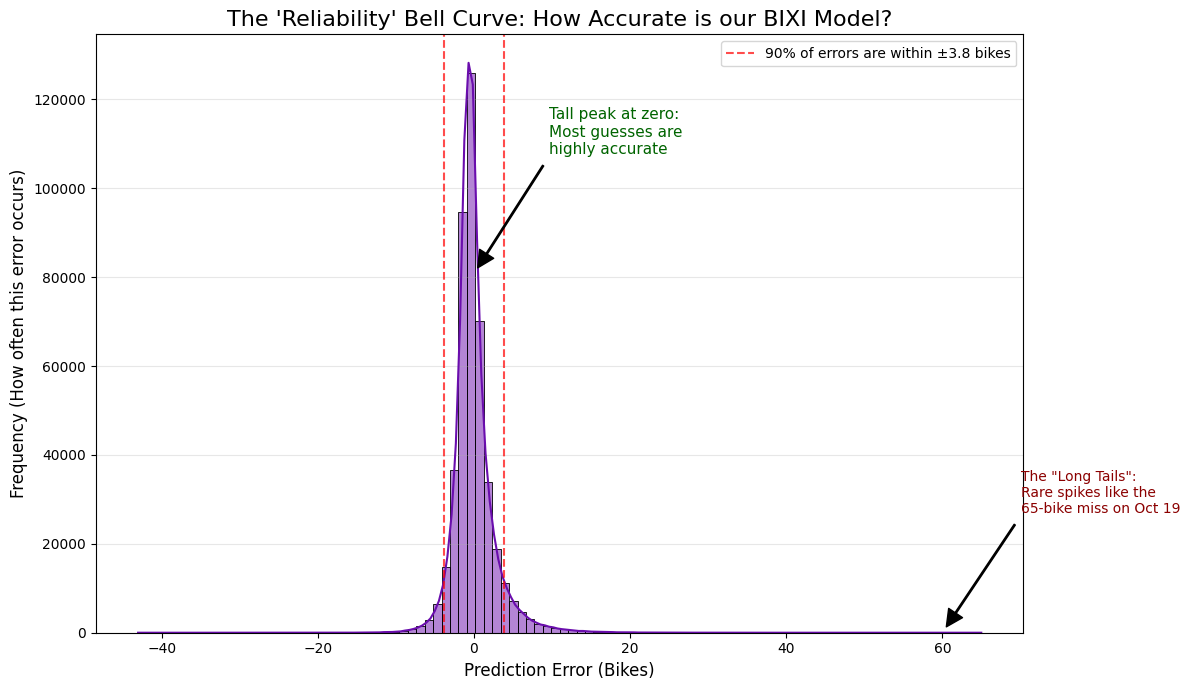

✅ Narrative Insight: 90% of the time, your model is within 3.8 bikes of the actual demand.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Ensure the analysis_df with residuals exists
# (Residual = Actual Demand - Predicted Demand)
analysis_df = predictions.withColumn("residual", F.col(target_col) - F.col("prediction"))

# 2. Extract residuals to Pandas for plotting
# We use a sample if the data is massive, but the test set should fit in memory
residuals_pd = analysis_df.select("residual").toPandas()

# 3. Calculate the actual "90% Reliability" stat for your report
abs_errors = np.abs(residuals_pd['residual'])
threshold_90 = np.percentile(abs_errors, 90)

# 4. Create the Visualisation
plt.figure(figsize=(12, 7))
sns.histplot(residuals_pd['residual'], kde=True, color='#6a0dad', bins=100)

# Add the "90% Reliability" lines
plt.axvline(-threshold_90, color='red', linestyle='--', alpha=0.7, 
            label=f'90% of errors are within ±{threshold_90:.1f} bikes')
plt.axvline(threshold_90, color='red', linestyle='--', alpha=0.7)

# Formatting for the Layperson
plt.title("The 'Reliability' Bell Curve: How Accurate is our BIXI Model?", fontsize=16)
plt.xlabel("Prediction Error (Bikes)", fontsize=12)
plt.ylabel("Frequency (How often this error occurs)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)

# Add Narrative Annotations
plt.annotate('Tall peak at zero:\nMost guesses are\nhighly accurate', 
             xy=(0, plt.gca().get_ylim()[1]*0.6), 
             xytext=(threshold_90*2.5, plt.gca().get_ylim()[1]*0.8),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             fontsize=11, color='darkgreen')

plt.annotate('The "Long Tails":\nRare spikes like the\n65-bike miss on Oct 19', 
             xy=(60, 5), xytext=(70, plt.gca().get_ylim()[1]*0.2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             fontsize=10, color='darkred')

plt.tight_layout()
plt.show()

print(f"✅ Narrative Insight: 90% of the time, your model is within {threshold_90:.1f} bikes of the actual demand.")

--------------- TREE MODELS FOR EXPLORATION ---------------

Task 8: The Random Forest Pipeline

In [14]:
def build_rf_pipeline(df, target_col):
    stages = []
    assembler_inputs = [
        "temp", "precip", "is_holiday", "is_weekend", "day_of_week", 
        "dist_km", "hour_sin", "hour_cos", "lag_1h_outflow"
    ]
    
    for c in ["transit_proximity_tier", "community"]:
        if df.select(c).distinct().count() > 1:
            indexer = StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
            encoder = OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_vec")
            stages += [indexer, encoder]
            assembler_inputs.append(f"{c}_vec")
            
    stages.append(VectorAssembler(inputCols=assembler_inputs, outputCol="features"))
    
    # LIGHTER SETTINGS: 20 trees, maxDepth 7
    rf = RandomForestRegressor(featuresCol="features", labelCol=target_col, 
                               numTrees=20, maxDepth=7, seed=42)
    stages.append(rf)
    
    return Pipeline(stages=stages)

Task 9: Training Random Forest

In [17]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder
from pyspark.ml.regression import RandomForestRegressor
import pyspark.sql.functions as F
import pandas as pd

print("✅ Random Forest tools imported and ready.")

✅ Random Forest tools imported and ready.


In [18]:
rf_metrics = []

for y in sorted(year_split_meta.keys()):
    print(f"🌲 Training Random Forest for {y}...")
    split_ts = year_split_meta[y]["split_ts"]
    
    # Use the advanced dataframe with lags and cyclical features
    train_sdf = model_sdf_final.where((F.col("ride_year") == y) & (F.col("ts_hour") < split_ts))
    test_sdf = model_sdf_final.where((F.col("ride_year") == y) & (F.col("ts_hour") >= split_ts))

    # 1. Fit the Lighter RF Pipeline
    rf_pipeline = build_rf_pipeline(train_sdf, target_col)
    rf_model = rf_pipeline.fit(train_sdf)
    rf_predictions = rf_model.transform(test_sdf)
    
    # 2. Extract Feature Importance
    rf_stage = rf_model.stages[-1]
    importances = rf_stage.featureImportances.toArray()
    
    # Extract metadata for naming
    meta = rf_predictions.schema["features"].metadata
    attrs = meta.get("ml_attr", {}).get("attrs", {})
    feature_names = ["unlabeled"] * len(importances)
    for attr_type in attrs:
        for attr in attrs[attr_type]:
            idx = attr.get("idx")
            if idx < len(feature_names):
                feature_names[idx] = attr.get("name")
            
    importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    print(f"--- 🏆 Top Predictors (Random Forest {y}) ---")
    display(importance_df.sort_values(by="Importance", ascending=False).head(10))

    # 3. Calculate Performance
    mae = rf_predictions.select(F.avg(F.abs(F.col(target_col) - F.col("prediction")))).first()[0]
    rf_metrics.append({"Year": y, "RF_MAE": mae})

# Final Summary
display(pd.DataFrame(rf_metrics))

🌲 Training Random Forest for 2024...


--- 🏆 Top Predictors (Random Forest 2024) ---


,Feature,Importance
8,lag_1h_outflow,0.770618
6,hour_sin,0.081776
7,hour_cos,0.057281
0,temp,0.036644
5,dist_km,0.034888
10,transit_proximity_tier_vec_Tier 3: Transit Desert,0.006970
3,is_weekend,0.004489
1,precip,0.003078
11,transit_proximity_tier_vec_Tier 1: High Proximity,0.002105
4,day_of_week,0.002053


🌲 Training Random Forest for 2025...


--- 🏆 Top Predictors (Random Forest 2025) ---


,Feature,Importance
8,lag_1h_outflow,0.757180
6,hour_sin,0.080654
7,hour_cos,0.056084
5,dist_km,0.043724
0,temp,0.041947
10,transit_proximity_tier_vec_Tier 3: Transit Desert,0.009945
3,is_weekend,0.004556
11,transit_proximity_tier_vec_Tier 1: High Proximity,0.002549
4,day_of_week,0.001939
1,precip,0.001092


,Year,RF_MAE
0,2024,1.874400
1,2025,1.712684


comparision of RF and LR

🚀 Training Linear Regression...


🌲 Training Random Forest...


/var/folders/td/nym30d4x2bs8b9q8z74d8v2m0000gn/T/ipykernel_31527/1549961283.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Mean Absolute Error (Lower is Better)", data=comparison_df, palette=["#1f77b4", "#2ca02c"])


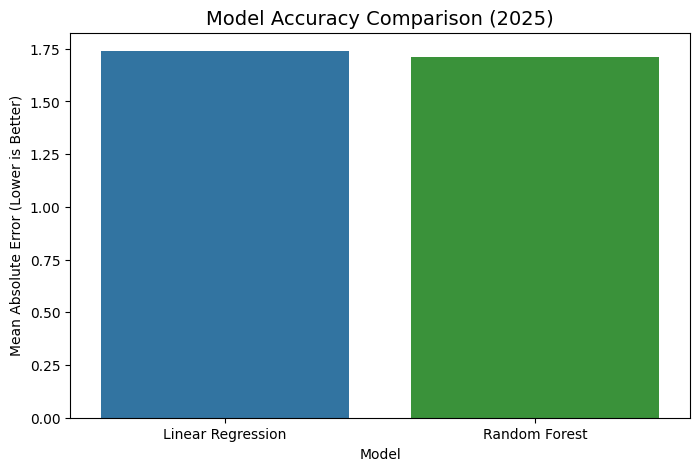

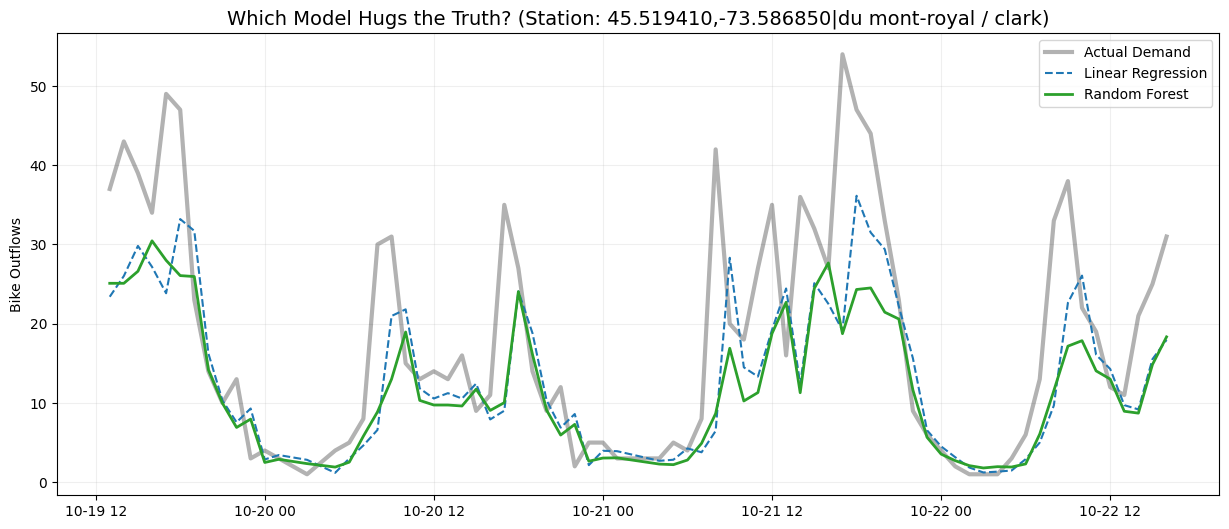

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Setup the 2025 Test Year
y = 2025
split_ts = year_split_meta[y]["split_ts"]
train_sdf = model_sdf_final.where((F.col("ride_year") == y) & (F.col("ts_hour") < split_ts))
test_sdf = model_sdf_final.where((F.col("ride_year") == y) & (F.col("ts_hour") >= split_ts))

# 2. Train both models
print("🚀 Training Linear Regression...")
lr_model = build_advanced_pipeline(train_sdf, target_col).fit(train_sdf)
lr_preds = lr_model.transform(test_sdf)

print("🌲 Training Random Forest...")
rf_model = build_rf_pipeline(train_sdf, target_col).fit(train_sdf)
rf_preds = rf_model.transform(test_sdf)

# 3. Calculate Global MAE for both
lr_mae = lr_preds.select(F.avg(F.abs(F.col(target_col) - F.col("prediction")))).first()[0]
rf_mae = rf_preds.select(F.avg(F.abs(F.col(target_col) - F.col("prediction")))).first()[0]

# --- VISUALIZATION 1: Accuracy Bar Chart ---
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "Mean Absolute Error (Lower is Better)": [lr_mae, rf_mae]
})

plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="Mean Absolute Error (Lower is Better)", data=comparison_df, palette=["#1f77b4", "#2ca02c"])
plt.title(f"Model Accuracy Comparison ({y})", fontsize=14)
plt.show()

# --- VISUALIZATION 2: The "Truth Tracker" (Actual vs Both Models) ---
# Pick the top station again for a clear visual
top_station_id = (rf_preds.groupBy("canonical_station_id").agg(F.sum(target_col).alias("total"))
                  .orderBy(F.desc("total")).limit(1).collect()[0]["canonical_station_id"])

# Get 72 hours (3 days) of data
vis_pd = (test_sdf.where(F.col("canonical_station_id") == top_station_id)
          .join(lr_preds.select("ts_hour", "canonical_station_id", F.col("prediction").alias("lr_pred")), 
                ["ts_hour", "canonical_station_id"])
          .join(rf_preds.select("ts_hour", "canonical_station_id", F.col("prediction").alias("rf_pred")), 
                ["ts_hour", "canonical_station_id"])
          .orderBy("ts_hour").limit(72).toPandas())

plt.figure(figsize=(15, 6))
plt.plot(vis_pd['ts_hour'], vis_pd[target_col], label='Actual Demand', color='black', linewidth=3, alpha=0.3)
plt.plot(vis_pd['ts_hour'], vis_pd['lr_pred'], label='Linear Regression', color='#1f77b4', linestyle='--')
plt.plot(vis_pd['ts_hour'], vis_pd['rf_pred'], label='Random Forest', color='#2ca02c', linewidth=2)

plt.title(f"Which Model Hugs the Truth? (Station: {top_station_id})", fontsize=14)
plt.ylabel("Bike Outflows")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()